In [55]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import sys
import os
import pathlib
import pickle

from omegaconf import OmegaConf

In [19]:
run_info_dict = {
    "random": list(),
    "neighbors": list(),
    "pos": list()
}

In [20]:
path = pathlib.Path(r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\dumps\random_init_old')
print(f"{path=}")

adj_seed_ls = np.array([12123, 1355, 13702, 13928, 14038, 1671, 1766, 1930, 2267, 2347, 278, 31726, 35588, 357, 37411, 48590, 54566, 5762, 59953, 60636, 629, 7150, 74, 7563, 7690])
weights_seed_ls = np.full_like(adj_seed_ls, fill_value=42)
run_name = ""

for adj_seed, weights_seed in zip(adj_seed_ls, weights_seed_ls):
    # with open(path / f"dump_{run_name}_seed_{weights_seed}_adj_{adj_seed}.bin", 'rb') as f:
    with open(path / f"seed_{weights_seed}_adj_{adj_seed}.bin", 'rb') as f:
        run_info = pickle.load(f)
        run_info = {
            'train_curve': run_info
        }
    
    run_info_dict['random'].append(run_info)

path=WindowsPath('C:/Users/Vladimir/PycharmProjects/EEGPatternRecognition/dumps/random_init_old')


In [21]:
path = pathlib.Path(r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\dumps\neighbors_init')
print(f"{path=}")

adj_seed_ls=np.array([428, 11923, 445, 5794, 14642, 43219, 2267, 11469, 15392, 1108, 665, 1462, 32026, 59966, 377, 269])
weights_seed_ls=np.array([428, 11923, 445, 5794, 14642, 43219, 2267, 11469, 15392, 1108, 665, 1462, 32026, 59966, 377, 269])
run_name = "neighbors_init"

for adj_seed, weights_seed in zip(adj_seed_ls, weights_seed_ls):
    with open(path / f"dump_{run_name}_seed_{weights_seed}_adj_{adj_seed}.bin", 'rb') as f:
        run_info = pickle.load(f)
    
    run_info_dict['neighbors'].append(run_info)

path=WindowsPath('C:/Users/Vladimir/PycharmProjects/EEGPatternRecognition/dumps/neighbors_init')


In [22]:
path = pathlib.Path(r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\dumps\pos_init')
print(f"{path=}")

adj_seed_ls=np.array([428, 11923, 445, 5794, 14642, 43219, 2267, 11469, 15392, 1108, 665, 1462, 32026, 59966, 377, 269])
weights_seed_ls=np.array([428, 11923, 445, 5794, 14642, 43219, 2267, 11469, 15392, 1108, 665, 1462, 32026, 59966, 377, 269])
run_name = "pos_init"

for adj_seed, weights_seed in zip(adj_seed_ls, weights_seed_ls):
    with open(path / f"dump_{run_name}_seed_{weights_seed}_adj_{adj_seed}.bin", 'rb') as f:
        run_info = pickle.load(f)
    
    run_info_dict['pos'].append(run_info)

path=WindowsPath('C:/Users/Vladimir/PycharmProjects/EEGPatternRecognition/dumps/pos_init')


In [26]:
run_info_dict.keys()

dict_keys(['random', 'neighbors', 'pos'])

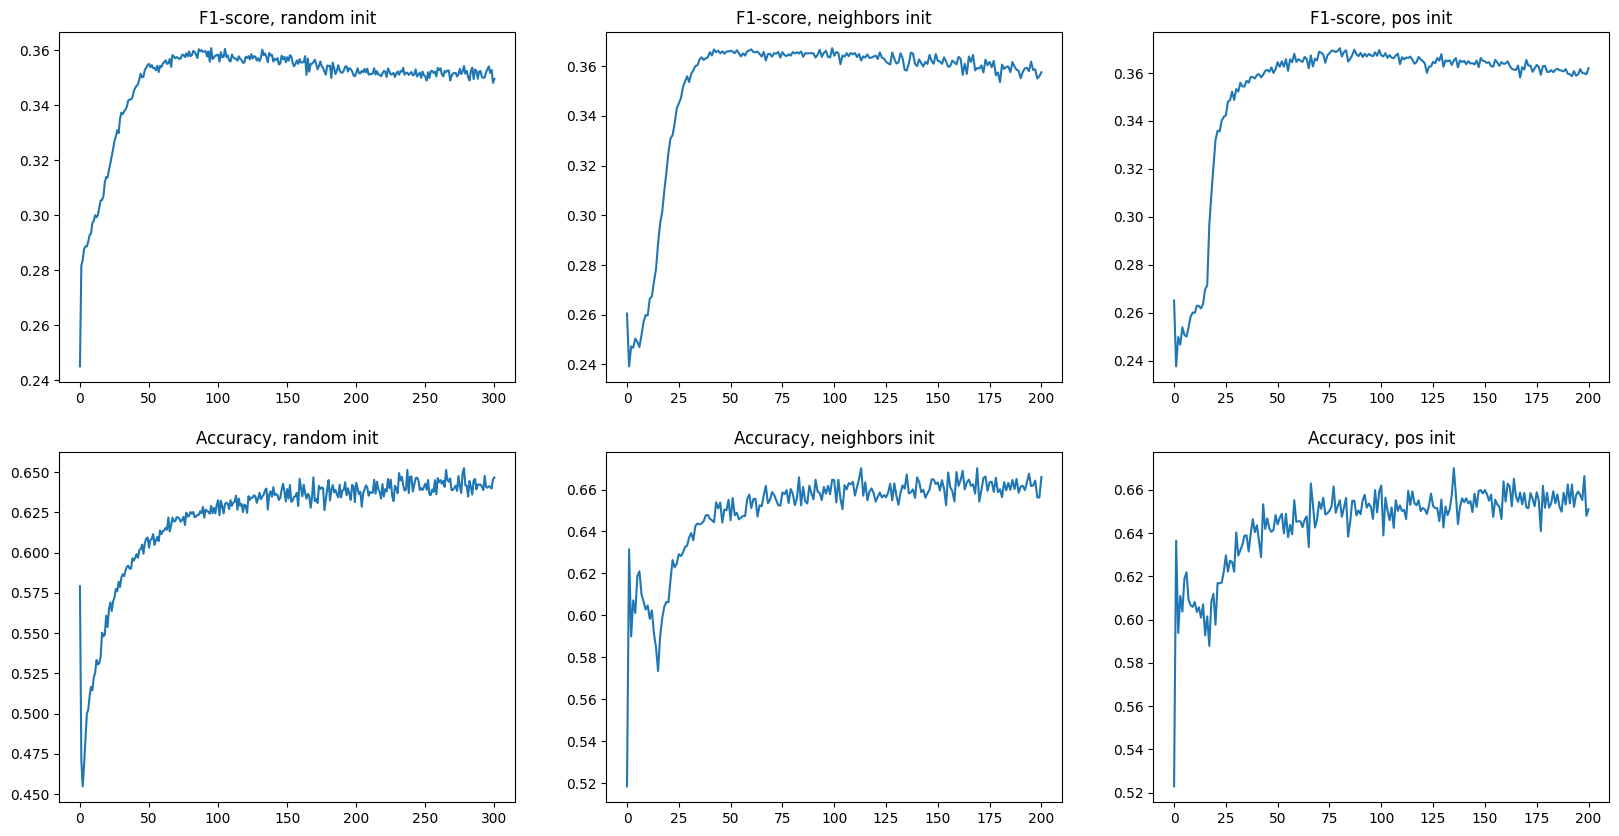

In [29]:
_, ax = plt.subplots(ncols=3, nrows=2, figsize=(20, 10))

for i, run_name in enumerate(run_info_dict.keys()): 
    ax[0, i].plot(run_info_dict[run_name][0]['train_curve']['validation']['f1'])
    ax[1, i].plot(run_info_dict[run_name][0]['train_curve']['validation']['accuracy'])

    ax[0, i].set_title(f'F1-score, {run_name} init')
    ax[1, i].set_title(f'Accuracy, {run_name} init')

In [30]:
f1 = {run_name: list() for run_name in run_info_dict.keys()}
accuracy = {run_name: list() for run_name in run_info_dict.keys()}

for run_name in run_info_dict.keys():
    for run_info in run_info_dict[run_name]:
        f1[run_name].append(run_info['train_curve']['validation']['f1'])
        accuracy[run_name].append(run_info['train_curve']['validation']['accuracy'])

    f1[run_name] = np.vstack(f1[run_name])
    accuracy[run_name] = np.vstack(accuracy[run_name])

    print(f"Run: {run_name}\t{f1[run_name].shape=}\t{accuracy[run_name].shape=}")

Run: random	f1[run_name].shape=(25, 301)	accuracy[run_name].shape=(25, 301)
Run: neighbors	f1[run_name].shape=(16, 201)	accuracy[run_name].shape=(16, 201)
Run: pos	f1[run_name].shape=(16, 201)	accuracy[run_name].shape=(16, 201)


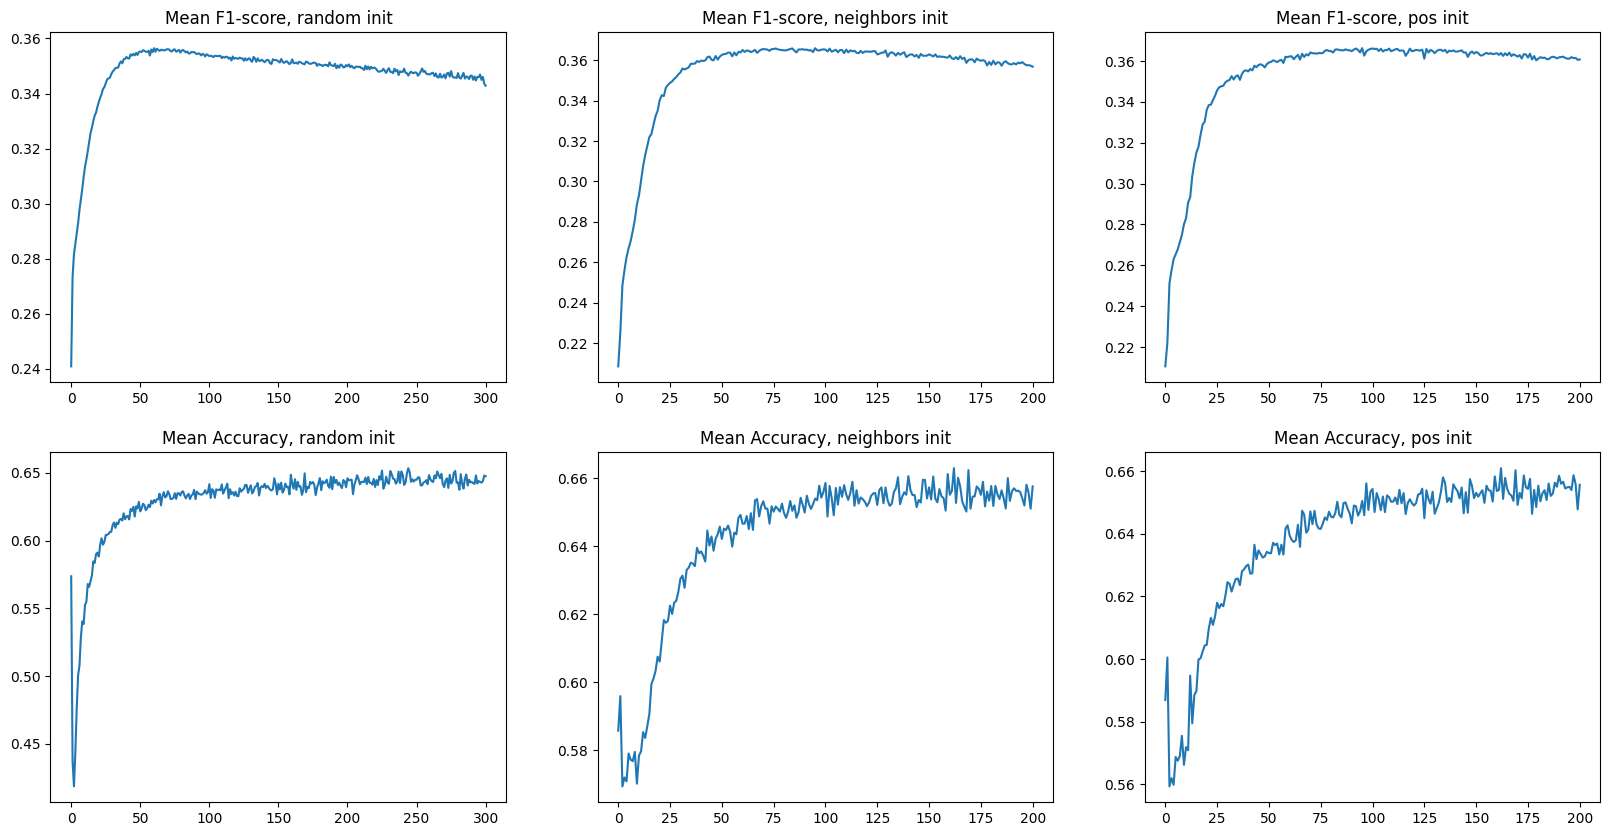

In [31]:
_, ax = plt.subplots(ncols=3, nrows=2, figsize=(20, 10))

for i, run_name in enumerate(run_info_dict.keys()): 
    ax[0, i].plot(np.mean(f1[run_name], axis=0))
    ax[1, i].plot(np.mean(accuracy[run_name], axis=0))

    ax[0, i].set_title(f'Mean F1-score, {run_name} init')
    ax[1, i].set_title(f'Mean Accuracy, {run_name} init')

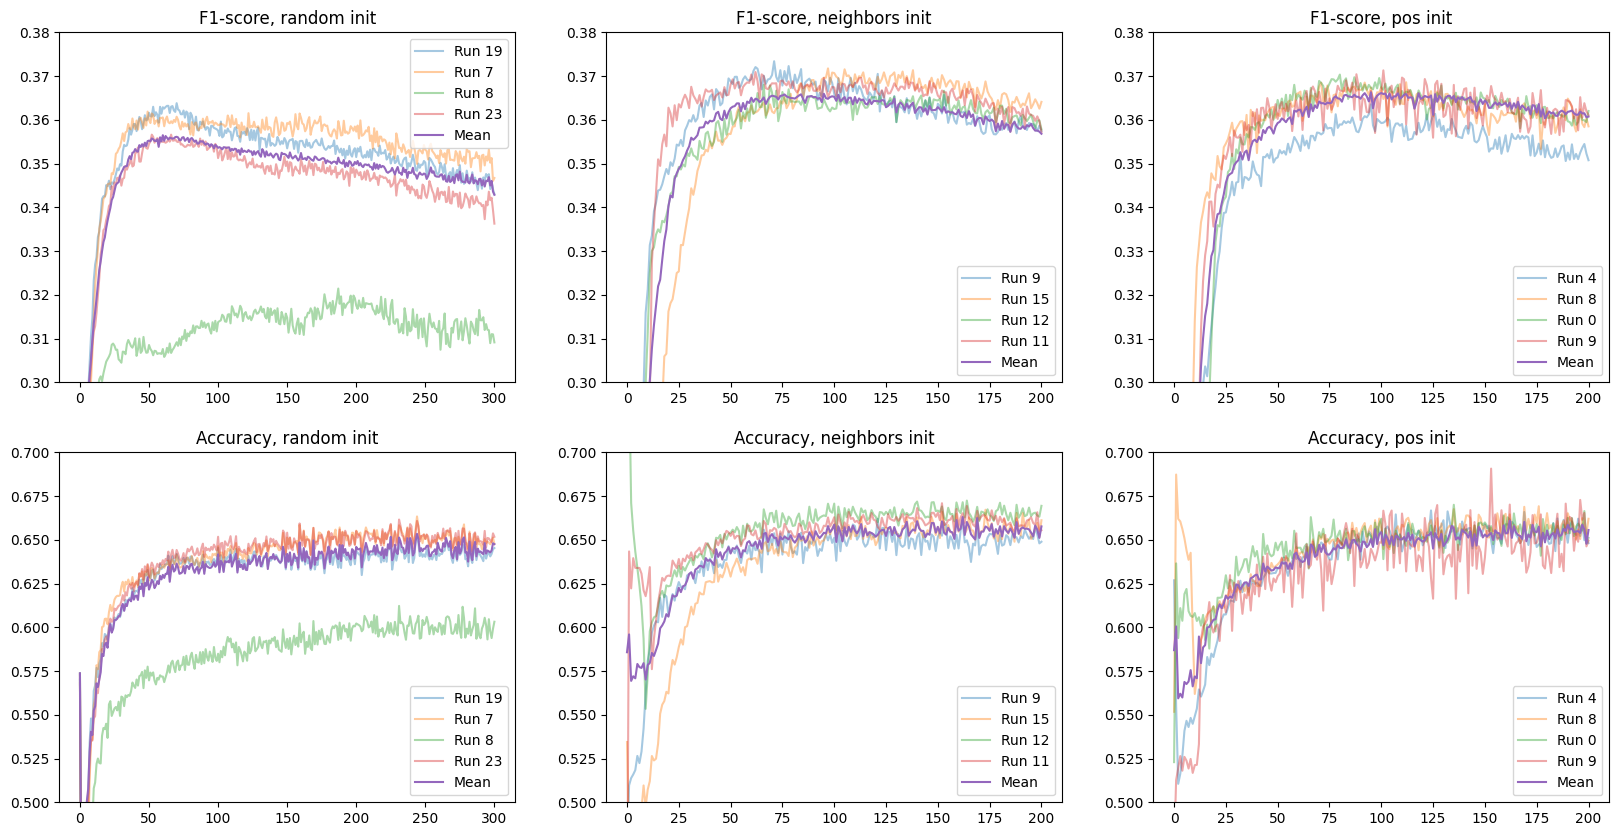

In [42]:
_, ax = plt.subplots(ncols=3, nrows=2, figsize=(20, 10))

for i, run_name in enumerate(run_info_dict.keys()): 
    rand_idxs = np.random.randint(0, f1[run_name].shape[0], size=4)

    for idx in rand_idxs:
        ax[0, i].plot(run_info_dict[run_name][idx]['train_curve']['validation']['f1'], label=f'Run {idx}', alpha=0.4)
        ax[1, i].plot(run_info_dict[run_name][idx]['train_curve']['validation']['accuracy'], label=f'Run {idx}', alpha=0.4)

    ax[0, i].plot(np.mean(f1[run_name], axis=0), label='Mean')
    ax[1, i].plot(np.mean(accuracy[run_name], axis=0), label='Mean')

    ax[0, i].set_title(f'F1-score, {run_name} init')
    ax[1, i].set_title(f'Accuracy, {run_name} init')

    ax[0, i].set_ylim((0.3, 0.38))
    ax[1, i].set_ylim((0.5, 0.7))

    ax[0, i].legend()
    ax[1, i].legend()

In [52]:
best_step_idxs = {}
best_f1 = {}
best_acc = {}

for run_name in run_info_dict.keys():
    best_step_idxs[run_name] = np.argmax(f1[run_name], axis=1)
    best_f1[run_name]  = f1[run_name][np.arange(best_step_idxs[run_name].shape[0]), best_step_idxs[run_name]]
    best_acc[run_name] = accuracy[run_name][np.arange(best_step_idxs[run_name].shape[0]), best_step_idxs[run_name]]

In [54]:
best_f1['random'].shape, best_acc['random'].shape

((25,), (25,))

<Axes: ylabel='f1'>

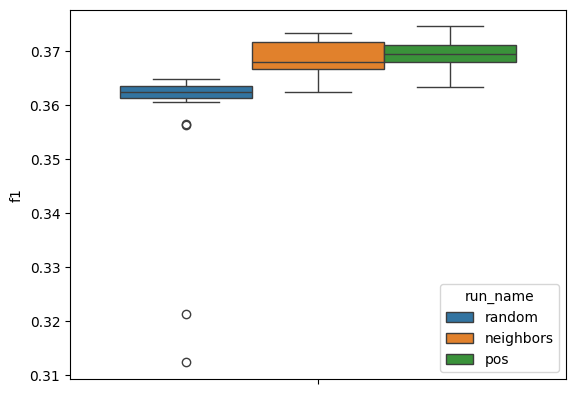

In [59]:
f1_df = pd.DataFrame(columns=['run_name', 'accuracy', 'f1'])

for run_name in run_info_dict.keys():
    for best_f1_val, best_acc_val in zip(best_f1[run_name], best_acc[run_name]):
        f1_df.loc[len(f1_df)] = [run_name, best_acc_val, best_f1_val]

sns.boxplot(data=f1_df, y='f1', hue='run_name')
# print(f"Mean F1-score: {np.mean(best_f1_ls)}\nMedian F1-score: {np.median(best_f1_ls)}")